<a href="https://colab.research.google.com/github/ayushbiitg/neuralNetworksLearnings/blob/main/Backpropogation_micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import these
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

About derivatives -> 𝑓′(𝑥)=limℎ→0 (𝑓(𝑥+ℎ)−𝑓(𝑥)) / ℎ

In [ ]:
# function check

def f(x):
  return 3*x**2 - 4*x + 5

f(3.0)

20.0

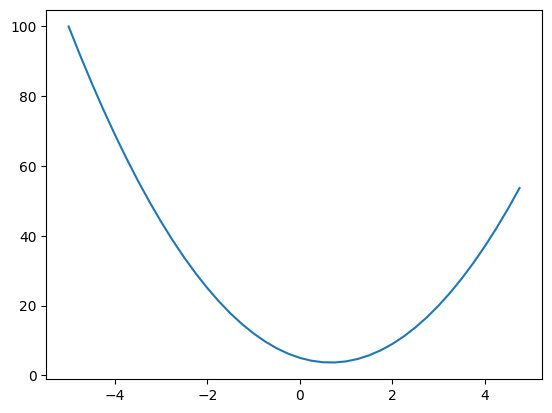

In [ ]:
#plot xs ys
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [ ]:
# calc slope
h = 0.001
x = 2/3
slope = (f(x+h) - f(x))/h
slope


0.0029999999995311555

In [ ]:
#set a,b,c & calc d
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


b,c:  -3.0 10.0
xa: [-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
ya: [25.   24.25 23.5  22.75 22.   21.25 20.5  19.75 19.   18.25 17.5  16.75
 16.   15.25 14.5  13.75 13.   12.25 11.5  10.75 10.    9.25  8.5   7.75
  7.    6.25  5.5   4.75  4.    3.25  2.5   1.75  1.    0.25 -0.5  -1.25
 -2.   -2.75 -3.5  -4.25]


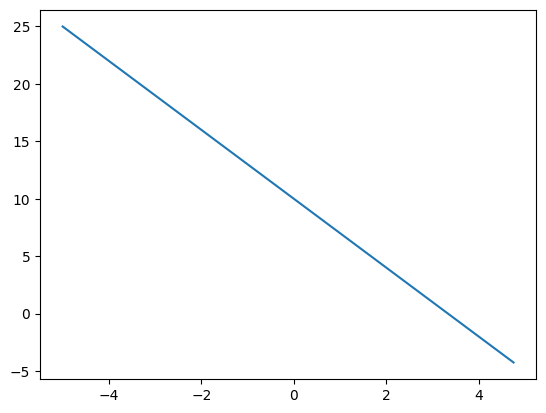

In [ ]:
xa = np.arange(-5, 5, 0.25)

print('b,c: ',b,c)
print('xa:',xa)
ya = lambda x: x*b +c
print('ya:',ya(xa))
plt.plot(xa, ya(xa))
# plt.plot()

In [ ]:
#slope
slope = (-4.25 - 25)/ (4.75 - (-5))
slope

-3.0

In [ ]:
#slope
h = 0.0001

D = (ya(xa + h) - ya(xa))/ h

In [ ]:
D

array([-3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3.])

# Backtracking

## Setup Value object & graph to visualize

In [29]:
class Value:
  def __init__(self, data, children=(), _op="", label=""):
    self.data = data
    self._prev = set(children)
    self.grad = 0.0 # by default we assume the variable has no effect on the L
    self._op = _op
    self.label = label
    self._backward = lambda: None


  def __repr__(self) -> str:
    return f"Value(data={self.data})"


  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data , (self, other), "+")


    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out


  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data , (self, other), "*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out


  def __pow__(self, other):
    assert isinstance(other, (int, float))
    out = Value(self.data**other, (self,), f"**{other}")

    def _backward():
      self.grad += other * (self.data**(other-1)) * out.grad
    out._backward = _backward
    return out


  def __rmul__(self, other): # other * self
    return self * other


  def __truediv__(self, other): # self / other
    return self * other**-1


  def __neg__(self):  # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other):
    return self + other

  def tanh(self):
    n = self.data
    t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out


  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out


  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)


    # initialize the end node grad to 1
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [18]:
# rough
# a = Value(2.0, label="a")
# b = Value(1.0, label="b")

# a-b

In [ ]:
# print(d._prev)
# print(d._op)

{Value(data=-6.0), Value(data=10.0)}
+


In [20]:
# Visualization

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | val %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

Note:

*   Grad is the derivative of L w.r.t. this value. Eg grad(a) -> dL/da
*   


## Example 1

In [ ]:
# setting grads mannually (calcuated on rough notebook)
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d*f; L.label = "L"

L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
b.grad = -4.0
a.grad = 6.0

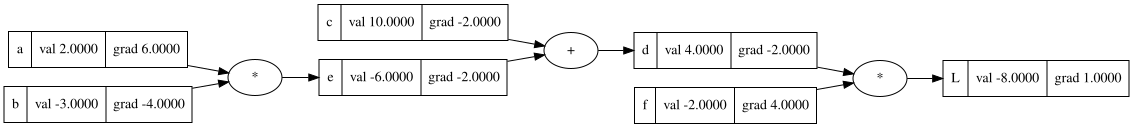

In [ ]:
draw_dot(L)

In [ ]:
# double cheking the derivate here using find grad
# use 𝑓′(𝑥)=limℎ→0 (𝑓(𝑥+ℎ)−𝑓(𝑥)) / ℎ

def find_grad():
  h = 0.001

  a = Value(2.0, label="a")
  b = Value(-3.0, label="b")
  c = Value(10.0, label="c")
  e = a*b; e.label = "e"
  d = e + c; d.label = "d"
  f = Value(-2.0, label="f")
  L = d*f; L.label = "L"
  L1 = L.data

  a = Value(2.0+h, label="a")
  b = Value(-3.0, label="b")
  c = Value(10.0, label="c")
  e = a*b; e.label = "e"
  d = e + c; d.label = "d"
  # d.data += h
  f = Value(-2.0, label="f")
  L = d*f; L.label = "L"
  L2 = L.data

  print((L2-L1)/h)


find_grad()

6.000000000000227


Notes:

- BP is recursive application of chain rule backwards through the computation graph



In [ ]:
# suppost i want to increase the value of L
# then we can just increase the leaf nodes (which we have control on, we decide them) whose grad is +ve
# and decrease for the ones with -ve grad

# Forward Pass by nudging all the var by a small value say 0.01
print("Previous values of a,b,c,d,e,f,L:",a.data,b.data,c.data,d.data,e.data,f.data,L.data)

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f

print("New value of L:",L.data)



Previous values of a,b,c,d,e,f,L: 2.0 -3.0 10.0 4.0 -6.0 -2.0 -8.0
New value of L: -7.286496


## Example 2 BP

- Artificial NN Neuron image

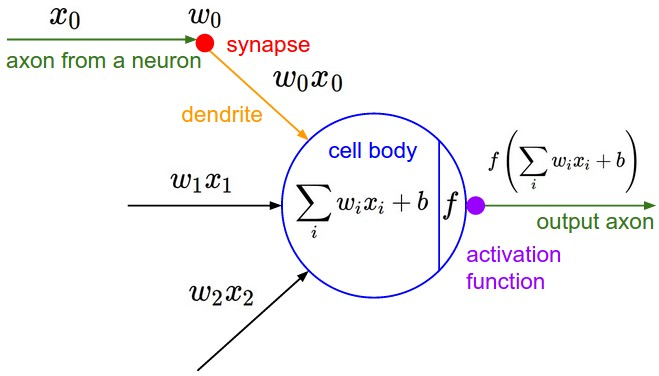

How It Fits into a Single Neuron Weighted Sum:
- The neuron multiplies each input (x) by a weight (w) and adds them together.
- Bias Addition: A bias (b) is added to shift the result up or down.
- Activation: The activation function (f) acts on this total:
    \\(\text{Output} = f(\sum (w \cdot x) + b)\)\\\\






### Setup variables, labels etc

In [ ]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.88137, label='b')
# x1w1 + x2w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


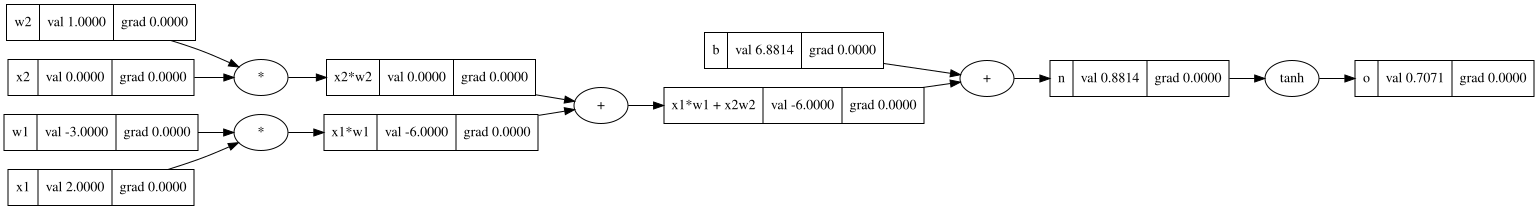

In [ ]:
draw_dot(o)

to find x1 grad, w1 grad ....

x2.grad = (w2.data)*(x2w2.grad)  
###(multiplication chain rule we've derived)
w2.grad = (x2.data)*(x2w2.grad)

similarly

x1.grad = (w1.data)*(x1w1.grad)

w1.grad = (x1.data)*(x1w1.grad)

### Iter 1: Mannual setting of grad functions (calculated on notebook)

n grad: 0.5000025364090595


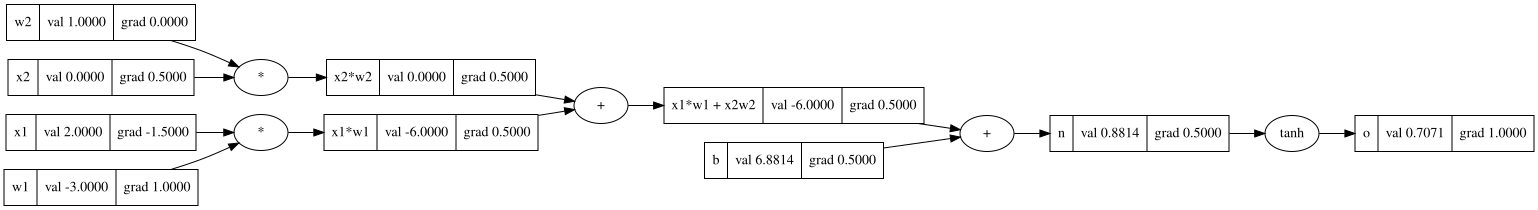

In [ ]:
# Mannual setting of grad functions

o.grad = 1.0

# n grad = do/dn
# d(tanh)/dx = 1 - (tanh)**2
# so do/dn = 1 - o**2
n.grad = 1 - o.data**2
print('n grad:', n.grad)

# now MANUALLY filling all the grad values
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

x1.grad = -3*0.5
x2.grad = 1*0.5
w1.grad = 2*0.5
w2.grad = 0*0.5




draw_dot(o)

### Iter2: calculating gradient using BACKTRACKING

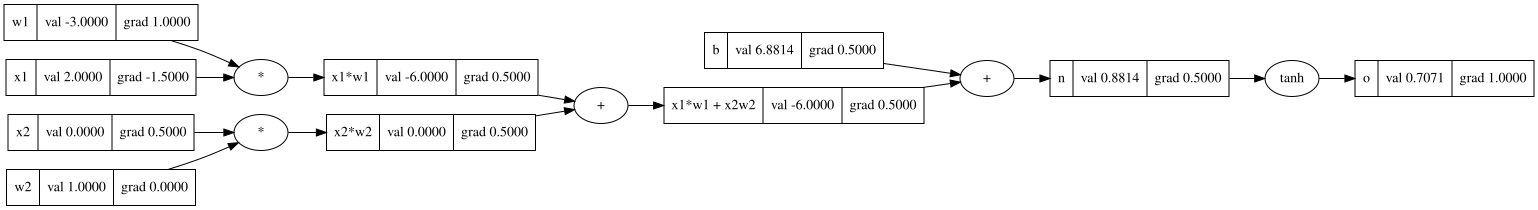

In [ ]:
# calculating gradient using BACKTRACKING

o.grad = 1.0

o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
w2._backward()

draw_dot(o)

### Iter3: Running backward prop on each node using Topological sort

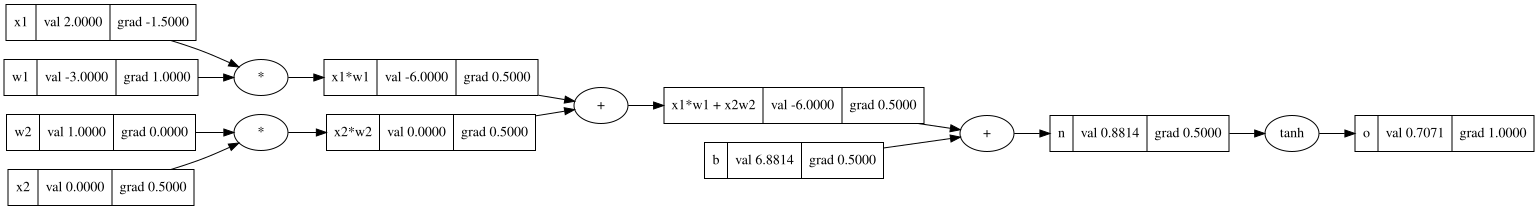

In [ ]:
# CALCULATING grads using backtrack with Topological sort
# topological sort help us to make the graph in one way
# so we do reverse(topo) & run the _backward function on each node

o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()

draw_dot(o)



### Iter4: calculating BT using one single run


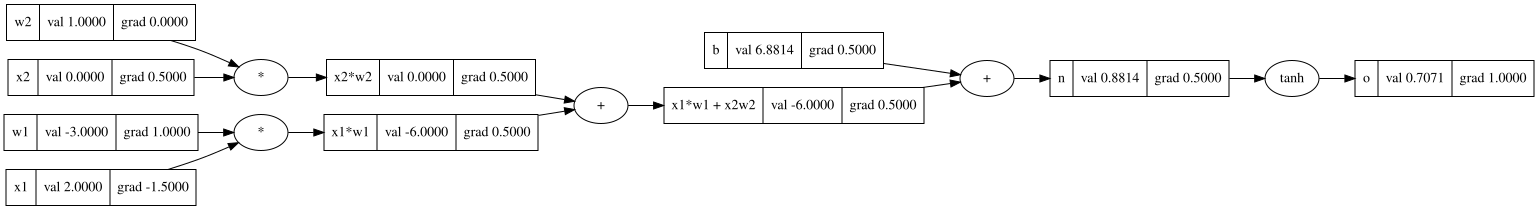

In [ ]:
# now we have added topological sort logic in Value class hence using it to:
#calculate BT using one single run

o.backward()

draw_dot(o)

### Iter5: breaking tanh to its exponential form

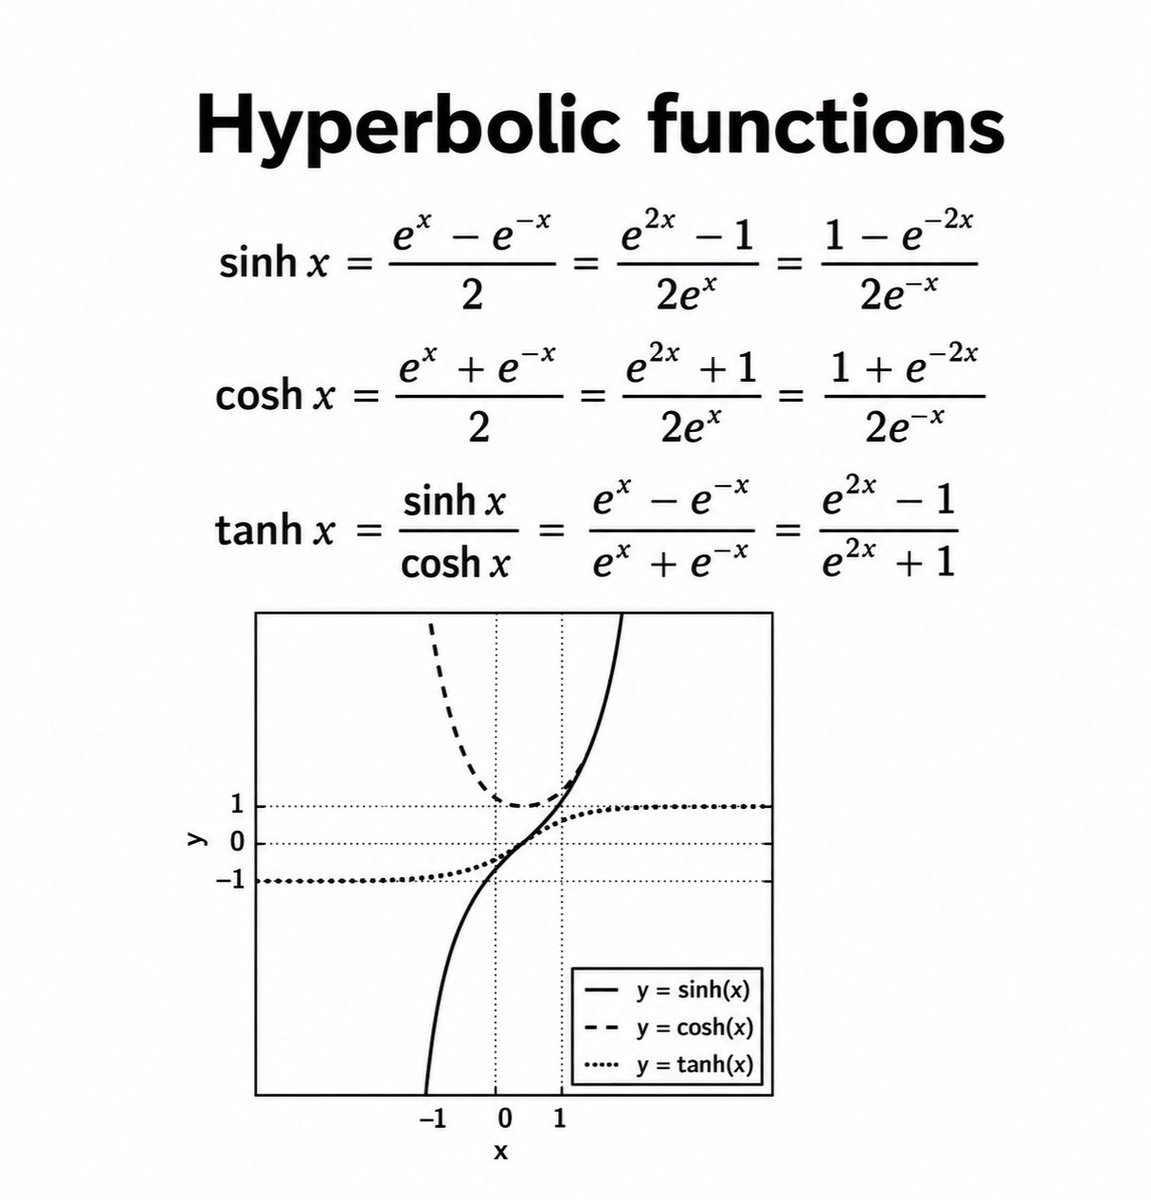

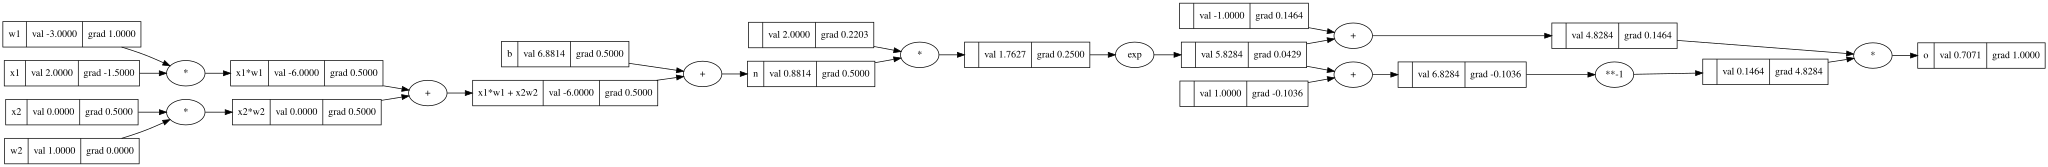

In [30]:
# lets break the tanh in exponential form & try this iter

# setting up variables again
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# -------------
e = (2*n).exp()
o = (e-1)/(e+1)
#---------

o.label = 'o'
o.backward()
draw_dot(o)

## Iter 6
Implementing backprop using Pytorch

In [44]:
import torch
import random

In [41]:

x1 = torch.Tensor([2.0]).double()     ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()     ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()     ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()     ; w2.requires_grad = True

b = torch.Tensor([6.88137]).double()  ; b.requires_grad = True

n = x1*w1 + x2*w2 +b

o = torch.tanh(n)
o.backward()

In [42]:
print('o', o.data.item())
print('-----')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

o 0.7071050214706146
-----
x1 -1.500007465833125
w1 1.0000049772220834
x2 0.5000024886110417
w2 0.0


Lets create a neuron

nin = number of inputs to that neuron

w = weights

b = controlls the overall happiness of the neuron

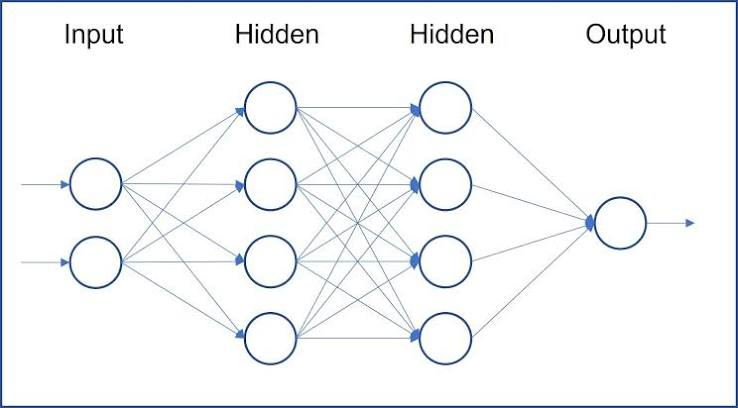

In [80]:
class Neuron:

  def __init__(self, nin) -> None:
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((xi*wi for xi, wi in zip(x, self.w)), self.b)
    return act

  # Above was a single neuron


# Below is a layer of neurons
class Layer:

  def __init__(self, nin, nout) -> None:
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs


# Below is a multi layer perceptron
class MLP:

  def __init__(self, nin, nouts) -> None:
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x = [2.0, 3.0]
# n = Neuron(2)  # This gives a neuron with 2 inputs & one output (Example the top neuron from the hidden layer)
# n = Layer(2, 4) # This gives a layer with input from 2 neurons & output to 4 (Example hidden layer 1)
n = MLP( 2, [4, 4, 1] )   # This gives the perceptron in the above image with 2 as starting inputs & defining the output of each layer -> 4, 4, 1
n(x)

Value(data=1.2017993638192332)

In [86]:
# another example

xs = [
    [2.0, 3.0],
    [3.0, -1.0],
    [0.5, 1.0],
    [1.0, 1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] ## desired targets

ypred = [n(x) for x in xs]
ypred

[Value(data=1.2017993638192332),
 Value(data=1.3733266861940625),
 Value(data=-1.7905267276218917),
 Value(data=-1.0210042894647566)]

In [ ]:
# calculating the loss as a single number to measure the overall performance

